In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from tqdm import tqdm

from the_archer.shot_model import get_data_dir, MakeGrid, _read_real_shots, _build_model, ShotModel
from endgame.ncaabb import NcaabbGender

In [2]:
data_root = get_data_dir(NcaabbGender.mens)
parquets = list(data_root.glob("*.parquet"))
grids = MakeGrid()
for path in tqdm(parquets):
    real_shots = _read_real_shots(path)
    grids.add_shot_df(real_shots)
jump_shot_model = _build_model(grids)
model = ShotModel(jump_shot_model, grids.special_probs)


100%|██████████| 70/70 [01:46<00:00,  1.52s/it]


/tmp/ipykernel_37690/3178119497.py:1: RuntimeWarning: invalid value encountered in divide
  accuracy_grid = grids.make_grid / grids.attempt_grid


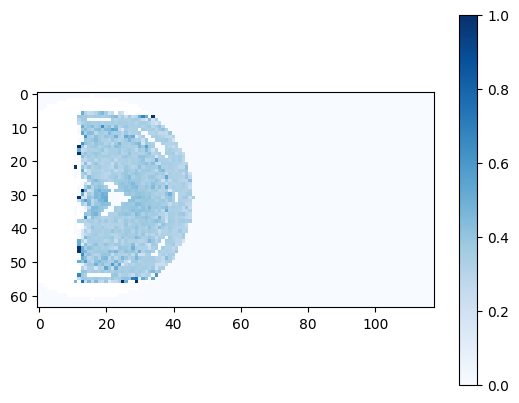

In [3]:
accuracy_grid = grids.make_grid / grids.attempt_grid
accuracy_grid[grids.distance_grid > 30] = 0
accuracy_grid[grids.attempt_grid > np.percentile(grids.attempt_grid.flatten(), 99)] = 0
plt.imshow(accuracy_grid, cmap="Blues")
plt.colorbar();

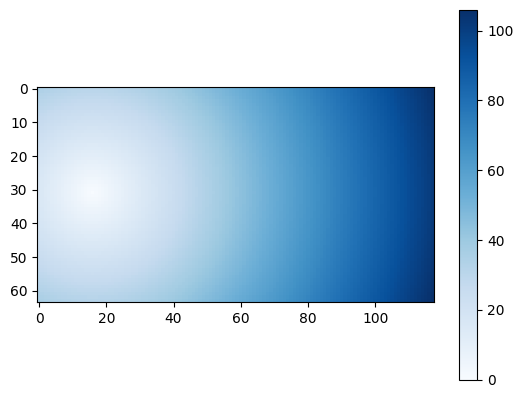

In [4]:
plt.imshow(grids.distance_grid, cmap="Blues")
plt.colorbar();

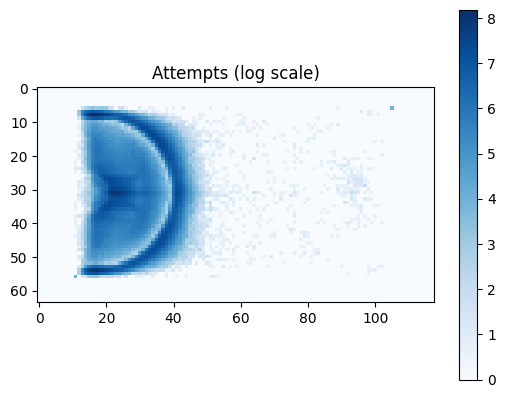

In [5]:
plt.imshow(np.log(grids.attempt_grid + 1), cmap="Blues")
plt.colorbar()
plt.title("Attempts (log scale)");

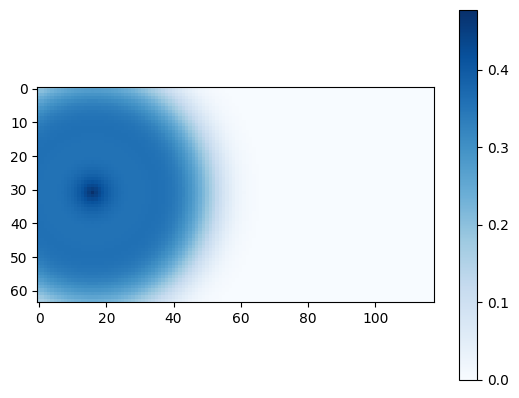

In [6]:
prob_grid = model._jump_shot.predict_proba(grids.distance_grid.ravel().reshape(-1, 1))[:, 1].reshape(grids.distance_grid.shape)
plt.imshow(prob_grid, cmap="Blues")
plt.colorbar();

In [7]:
bin_edges = np.arange(0, grids.distance_grid.flatten().max() + 1, 1)
bin_indices = np.digitize(grids.distance_grid, bins=bin_edges)
n_bins = len(bin_edges)
bin_makes    = np.zeros(n_bins)
bin_attempts = np.zeros(n_bins)

for i in range(grids.make_grid.shape[0]):
    for j in range(grids.make_grid.shape[1]):
        bin_idx = bin_indices[i, j]
        bin_makes[bin_idx] += grids.make_grid[i, j]
        bin_attempts[bin_idx] += grids.attempt_grid[i, j]


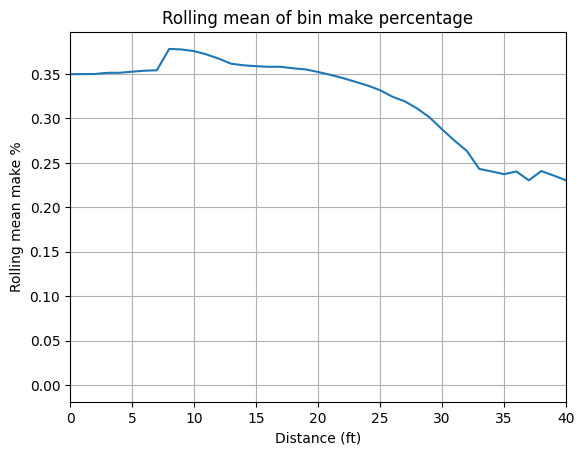

In [8]:
accuracy = np.divide(bin_makes, bin_attempts, out=np.zeros_like(bin_makes), where=bin_attempts != 0)
roll = pd.Series(accuracy).rolling(window=15, min_periods=1, center=True).mean()

plt.xlim(0, 40)
plt.plot(roll)
plt.xlabel("Distance (ft)")
plt.ylabel("Rolling mean make %")
plt.title("Rolling mean of bin make percentage")
plt.grid(True);

/tmp/ipykernel_37690/1784138972.py:22: RuntimeWarning: invalid value encountered in divide
  bin_accuracy = np.where(valid, bin_makes / bin_attempts, np.nan)


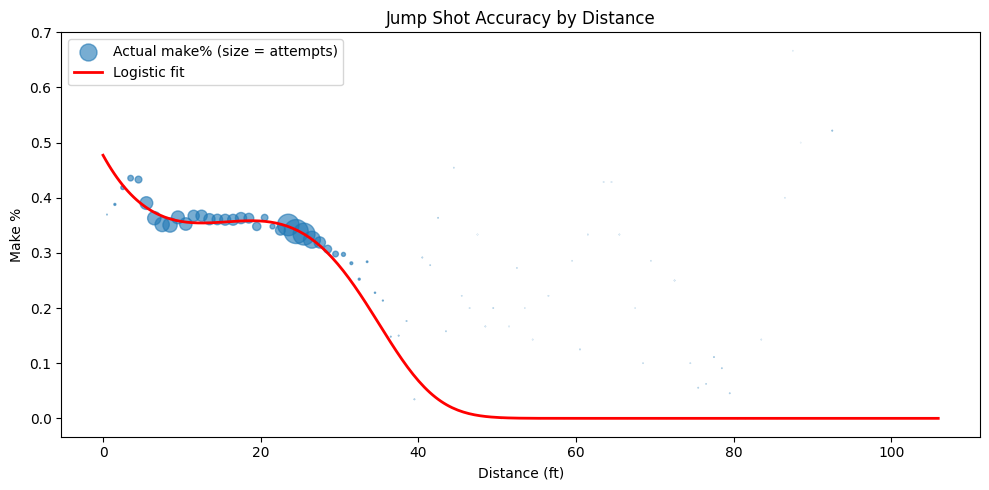

In [9]:
import matplotlib.pyplot as plt

distance_flat = grids.distance_grid.flatten()
makes_flat = grids.make_grid.flatten()
attempts_flat = grids.attempt_grid.flatten()

# --- Bin the flat arrays by distance ---
bin_edges = np.arange(0, distance_flat.max() + 1, 1)  # 1-foot bins
bin_indices = np.digitize(distance_flat, bin_edges) - 1  # 0-indexed

n_bins = len(bin_edges) - 1
bin_makes    = np.zeros(n_bins)
bin_attempts = np.zeros(n_bins)

for i in range(n_bins):
    mask = bin_indices == i
    bin_makes[i]    = makes_flat[mask].sum()
    bin_attempts[i] = attempts_flat[mask].sum()

# --- Compute accuracy, masking empty bins ---
valid = bin_attempts > 0
bin_accuracy = np.where(valid, bin_makes / bin_attempts, np.nan)
bin_centers  = bin_edges[:-1] + 0.5

# --- Fitted curve over distance range ---
dist_range = np.linspace(distance_flat.min(), distance_flat.max(), 300).reshape(-1, 1)
fitted_probs = model._jump_shot.predict_proba(dist_range)[:, 1]

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 5))

ax.scatter(
    bin_centers[valid],
    bin_accuracy[valid],
    s=bin_attempts[valid] / bin_attempts[valid].max() * 300,
    alpha=0.6,
    label="Actual make% (size = attempts)"
)
ax.plot(dist_range, fitted_probs, color="red", linewidth=2, label="Logistic fit")

ax.set_xlabel("Distance (ft)")
ax.set_ylabel("Make %")
ax.set_title("Jump Shot Accuracy by Distance")
ax.legend()
plt.tight_layout()
plt.show()

Huh...way flatter than I would've guessed.
I'm ignoring things I have like:
- Shot clock pressure
- Shooting fouls!?!?! (currently assuming that's not marked as a shot)
- Shot angle
- Half-court vs transition (sorta - I can figure out the play clock)

Things I don't have
- Defender distance

I'm also wondering if there's a lot to be found based on player shooting %.
Potentially defenses are calibrated to allow bad shooters to shoot,
so the distance isn't "shot difficulty for the average player taking the shot",
it's padded downward by 'bad' shots.

Poking around at [relevant](https://toddwschneider.com/posts/nba-vs-ncaa-basketball-shooting-performance/) [lit](https://duddhawork.com/ballbook/model.html) made me feel better